# Evaluation

In [1]:
import itertools
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Runs

In [2]:
PRICING = {
    'openai': {
        'gpt-5.4':      (2.5/1e6, 15./1e6),
        'gpt-5.4-mini': (.75/1e6, 4.5/1e6)}}

def cost(provider, model, input_tokens, output_tokens):
    try:
        l, r = PRICING[provider][model]
        return l * input_tokens + r * output_tokens
    except KeyError as err:
        return 0.
        
def load():
    for path in pathlib.Path('runs').glob('*.json'):
        with open(path, 'r', encoding='utf-8') as fp:
            t = json.load(fp)
            yield {
                'digest': t['digest'][:10],
                'Q': t['num_states'],
                'S': t['num_symbols'],
                'W': t['work_length'],
                'C': t['cycles_until_halt'],
                'provider': t['provider'],
                'model': t['model'],
                'prompt': t['prompt'],
                'temperature': t['temperature'],
                'seed': t['seed'],
                'truncate': f'yes({t["truncate"]})' if t['truncate'] is not None else 'no',
                'cycles': t['cycles'],
                'progress': t['cycles'] / t['cycles_until_halt'],
                'error': bool(t['error']),
                'halted': bool(t['halted']),
                # 'input_tokens': t['usage_metadata']['input_tokens'],
                # 'output_tokens': t['usage_metadata']['output_tokens'],
                'cost': cost(t['provider'],
                             t['model'],
                             t['usage_metadata']['input_tokens'],
                             t['usage_metadata']['output_tokens']),
            }
RUNS = list(load())
RUNS_DF = pd.DataFrame(RUNS)
RUNS_DF_SUM = RUNS_DF[['error', 'halted']].sum().to_frame(name='sum')
RUNS_DF_COST = RUNS_DF[['cost']].sum().to_frame(name='$')

In [3]:
display(RUNS_DF_COST)
display(RUNS_DF_SUM)
display(RUNS_DF.sort_values(by=['progress', 'cycles', 'cost'], ascending=False))

,$
cost,10.933903


,sum
error,26
halted,22


,digest,Q,S,W,C,provider,model,prompt,temperature,seed,truncate,cycles,progress,error,halted,cost
6,65999ff46d,32,2,64,60,openai,gpt-5.4,detailed-en,0.0,0,yes(0),60,1.000000,False,True,1.073538
22,d7c1f4bed9,16,2,32,30,openai,gpt-5.4,simple-pt,0.0,0,no,30,1.000000,False,True,1.201223
1,d7c1f4bed9,16,2,32,30,openai,gpt-5.4,detailed-en,0.0,0,no,30,1.000000,False,True,1.153783
13,4743971540,2,2,32,30,openai,gpt-5.4,simple-pt,0.0,0,no,30,1.000000,False,True,1.140388
15,4743971540,2,2,32,30,openai,gpt-5.4,detailed-en,0.0,0,no,30,1.000000,False,True,1.019895
0,4743971540,2,2,32,30,openai,gpt-5.4,detailed-en,0.0,0,yes(0),30,1.000000,False,True,0.389055
43,7ef6726625,32,2,16,15,openai,gpt-5.4,detailed-en,0.0,0,no,15,1.000000,False,True,0.381862
18,1fb3a2bf89,16,2,16,15,openai,gpt-5.4,simple-pt,0.0,0,no,15,1.000000,False,True,0.319312
2,7ef6726625,32,2,16,15,openai,gpt-5.4,detailed-en,0.0,0,yes(0),15,1.000000,False,True,0.218080
30,06deabae09,2,2,16,15,openai,gpt-5.4,simple-pt,0.0,0,yes(0),15,1.000000,False,True,0.179762


In [4]:
Qs = sorted(RUNS_DF['Q'].unique())
Ss = sorted(RUNS_DF['S'].unique())
Ws = sorted(RUNS_DF['W'].unique())
Cs = sorted(RUNS_DF['C'].unique())
PROVIDER = RUNS_DF['provider'].unique()
MODEL = RUNS_DF['model'].unique()
PROMPT = RUNS_DF['prompt'].unique()
TEMPERATURE = RUNS_DF['temperature'].unique()
SEED = RUNS_DF['seed'].unique()
TRUNCATE = RUNS_DF['truncate'].unique()
PROD_MODEL_CONFIG = list(itertools.product(PROVIDER, MODEL, PROMPT, TEMPERATURE, TRUNCATE))

## Progress

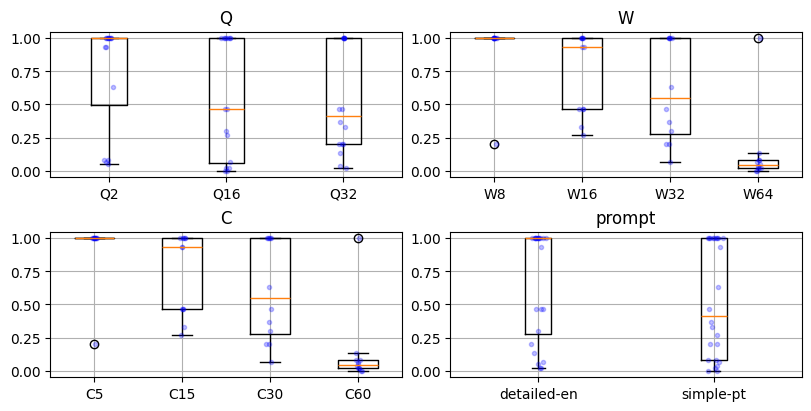

In [5]:
def it(X, Xs, label=None):
    for x in Xs:
        yield (RUNS_DF[(RUNS_DF[X] == x)]['progress'], f'{X if len(X) == 1 else ""}{x}')
xs, labels = zip(*it('Q', Qs))

fig, ax = plt.subplots(2, 2, figsize=(8,4), constrained_layout=True)
for k, (X, Xs) in enumerate((('Q', Qs), ('W', Ws), ('C', Cs), ('prompt', PROMPT))):
    xs, labels = zip(*it(X, Xs))
    i, j = k//2, k%2
    ax[i, j].boxplot(xs, tick_labels=labels)
    ax[i, j].grid(True)
    ax[i, j].set_title(X)
    for l in range(1, len(xs) + 1):
        y = xs[l-1]
        x = np.random.normal(l, 0.02, len(y))
        ax[i,j].plot(x, y, 'b.', alpha=0.25)
plt.show()

## Accuracy

In [6]:
providers = RUNS_DF['provider'].unique()
models = RUNS_DF['model'].unique()
prompts = RUNS_DF['prompt'].unique()
temperature = RUNS_DF['temperature'].unique()
truncate = RUNS_DF['truncate'].unique()
Cs = RUNS_DF['C'].unique()
Cs.sort()

In [7]:
import itertools
tab = {}
for provider, model, prompt, temp, tr in PROD_MODEL_CONFIG:
    t = RUNS_DF[
        (RUNS_DF['provider'] == provider)
        & (RUNS_DF['model'] == model)
        & (RUNS_DF['prompt'] == prompt)
        & (RUNS_DF['temperature'] == temp)
        & (RUNS_DF['truncate'] == tr)
    ].sort_values('cycles')
    label = f'{provider}-{model}-{prompt}-temp:{temp}-tr:{tr}'
    #print(label)
    for i in range(0, Cs[-1] + 1):
        N_correct = len(t[t['cycles'] >= i])
        N_total = len(t[t['C'] >= i])
        if N_total != 0:
            acc = N_correct / N_total
        else:
            acc = float('nan')
        if label not in tab:
            tab[label] = []
        tab[label].append(acc)

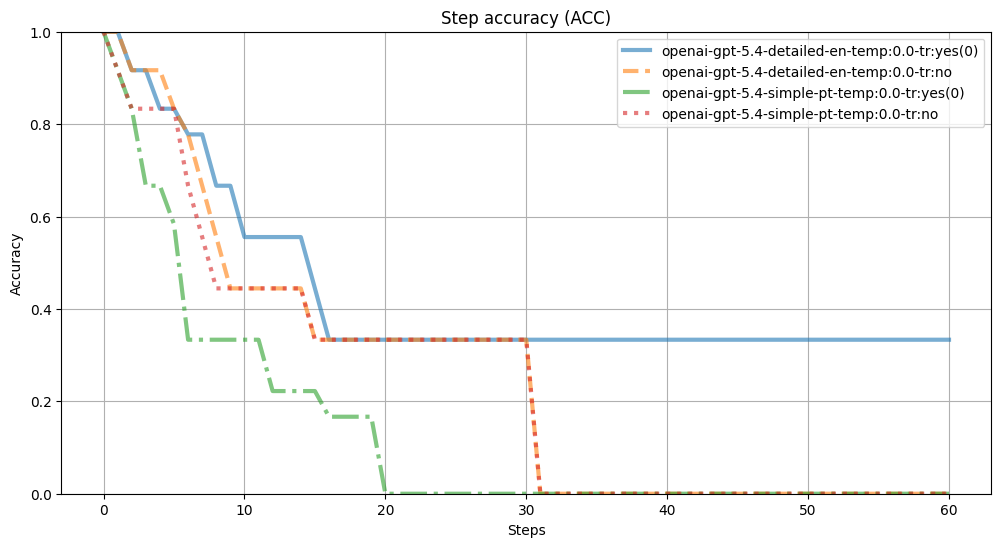

In [8]:
df = pd.DataFrame(tab, index=list(range(0, Cs[-1]+1)))
ax = df.plot.line(
    title='Step accuracy (ACC)',
    xlabel='Steps',
    ylabel='Accuracy',
    figsize=(12,6),
    grid=True, 
    style=['-', '--', '-.', ':'], 
    alpha=.6,
    linewidth=3,
)
ax.set_ylim(df.min().min(), df.max().max())
plt.show()

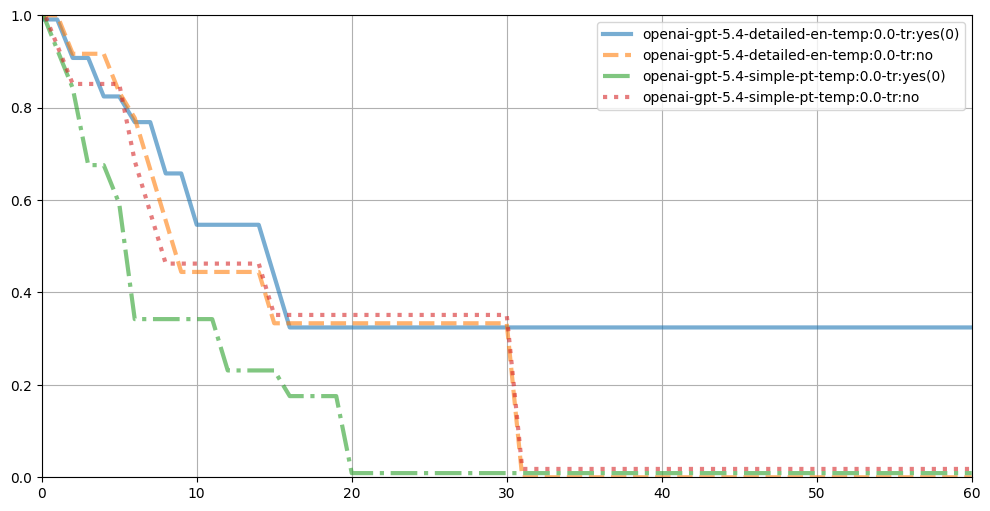

In [9]:
import matplotlib.transforms as mtrans
fig, ax = plt.subplots(figsize=(12,6))
ax.set_ylim(df.min().min(), df.max().max())
ax.set_xlim(0, 60)
ls = ['-', '--', '-.', ':']
for i, col in enumerate(df):
    df.plot(y=col, figsize=(12,6), ax=ax, alpha=.6, linewidth=3, style=ls[i],
            transform=mtrans.offset_copy(ax.transData, fig=fig, x=0.0, y=3*(i-1), units='points'))
ax.grid(True)